# <font color="brown">SVM Teaching Note </font>

## <font color = "brown">Purpose </font>
This is a from-scratch, detailed teaching note on **Support Vector Machines**, written to be taught from, not just read. It builds up every idea from plain intuition first, then the matching math in simple algebra (no heavy Lagrangian derivations), with a diagram at every step. It's the companion to `SVM.ipynb`, which applies these ideas to a real credit-default dataset.

## <font color = "brown">Contents </font>
1. The problem SVM solves
2. Margin & support vectors
3. The math of the boundary
4. A tiny worked example
5. Soft margins: when data isn't perfectly separable (the `C` parameter)
6. Non-linear data: why we need kernels
7. The common kernels
8. Why kernels work: a peek behind the curtain
9. Multi-class SVM, briefly
10. Strengths, weaknesses, and when to reach for SVM
11. Summary cheat sheet

In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_circles

%matplotlib inline

## <font color="brown"> 1. The Problem SVM Solves

Suppose you have two groups of points (two classes) plotted on a page, and you want to draw a boundary that separates them, so that anything new can be classified by which side of the boundary it falls on.

The immediate problem: **usually there isn't just one boundary that works.** Look at the picture below, every one of those dashed lines separates red from blue perfectly. So which one should we actually pick?

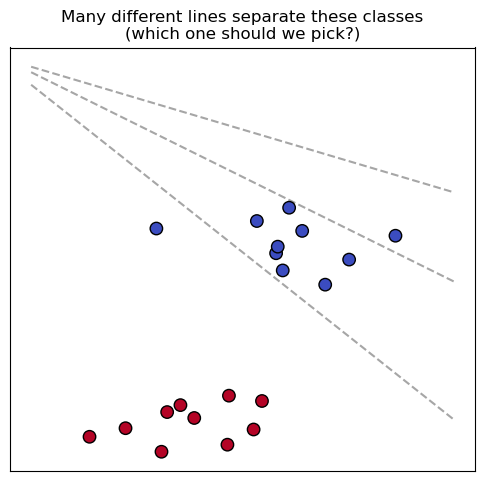

In [14]:
X_demo, y_demo = make_blobs(n_samples=20, centers=2, cluster_std=0.8, random_state=6)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(X_demo[:, 0], X_demo[:, 1], c=y_demo, cmap='coolwarm', edgecolors='k', s=80, zorder=3)
xx = np.linspace(X_demo[:, 0].min() - 1, X_demo[:, 0].max() + 1, 10)
for slope, intercept in [(-1, 6.5), (-0.6, 5.2), (-1.6, 8.3)]:
    ax.plot(xx, slope * xx + intercept, '--', color='gray', alpha=0.7)
ax.set_title('Many different lines separate these classes\n(which one should we pick?)')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

**SVM's answer**: out of every line that separates the classes, pick the one that stays as far away as possible from *both* groups. Intuitively, a line that barely squeezes between the two groups is fragile, a new point only slightly different from what we've seen could easily land on the wrong side. A line with plenty of breathing room on both sides is safer.

## <font color="brown"> 2. Margin & Support Vectors

The gap between the boundary and the nearest point of each class is called the **margin**. SVM picks the boundary that makes this margin as *wide* as possible, this is called the **maximum-margin classifier**.

The points that end up exactly on the edge of that margin (the closest points from each class) are called **support vectors**. They are the *only* points that matter for defining the boundary, if you deleted every other point and re-trained, you'd get the exact same boundary. That's also where the name "Support Vector Machine" comes from.

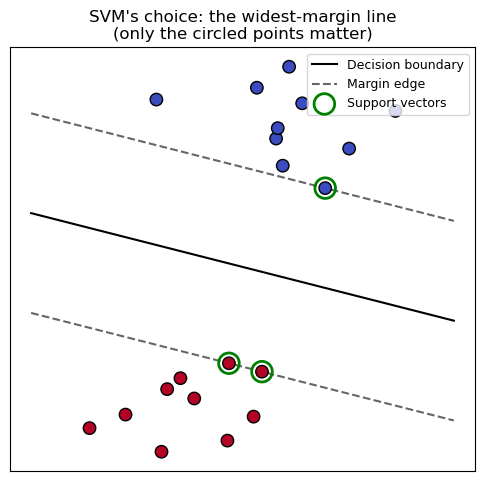

In [17]:
model = SVC(kernel='linear', C=1000).fit(X_demo, y_demo)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(X_demo[:, 0], X_demo[:, 1], c=y_demo, cmap='coolwarm', edgecolors='k', s=80, zorder=3)

w = model.coef_[0]
b = model.intercept_[0]
xx = np.linspace(X_demo[:, 0].min() - 1, X_demo[:, 0].max() + 1, 10)
yy = -(w[0] * xx + b) / w[1]
margin = 1 / np.sqrt(np.sum(w ** 2))
factor = np.sqrt(1 + (w[0] / w[1]) ** 2)

ax.plot(xx, yy, 'k-', label='Decision boundary')
ax.plot(xx, yy + factor * margin, 'k--', alpha=0.6, label='Margin edge')
ax.plot(xx, yy - factor * margin, 'k--', alpha=0.6)
ax.scatter(
    model.support_vectors_[:, 0], model.support_vectors_[:, 1],
    s=220, facecolors='none', edgecolors='green', linewidths=2,
    label='Support vectors', zorder=4,
)
ax.set_title("SVM's choice: the widest-margin line\n(only the circled points matter)")
ax.legend(loc='upper right', fontsize=9)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

Notice: out of 20 points, only 3 are circled as support vectors. The other 17 could move around freely (as long as they don't cross into the margin) and the boundary wouldn't change at all.

## <font color="brown"> 3. The Math of the Boundary

You already know the equation of a straight line in 2D: $y = mx + c$. SVM writes this in a slightly more general form that works in any number of dimensions, however many features/columns your data has:

$$w \cdot x + b = 0$$

* $x$ is a data point (a row of feature values)
* $w$ is a vector of weights, one per feature. It controls the **direction/tilt** of the boundary, just like the slope $m$ does for a 2D line.
* $b$ is a single number that shifts the boundary, just like the intercept $c$ does.

To classify a new point, we just check which side of the boundary it's on:

$$\text{predict } +1 \text{ if } w \cdot x + b \ge 0, \qquad \text{predict } -1 \text{ if } w \cdot x + b < 0$$

That's the entire model, just the numbers stored in $w$ and $b$.

### <font color="blue"> How wide is the margin, exactly?

It turns out (we'll just state this fact rather than derive it) that the margin width is exactly:

$$\text{margin width} = \frac{2}{\lVert w \rVert}$$

where $\lVert w \rVert$ is simply the length of the vector $w$ (ordinary Pythagoras, if $w = (w_1, w_2)$ then $\lVert w \rVert = \sqrt{w_1^2 + w_2^2}$).

Since the margin is $2$ divided by $\lVert w \rVert$, **making the margin as wide as possible is exactly the same thing as making $\lVert w \rVert$ as small as possible.** So the entire training problem becomes:

$$\text{minimize } \lVert w \rVert \quad \text{subject to every point being correctly classified with at least 1 unit of safety margin}$$

Written out, that constraint is: for every training point $(x_i, y_i)$, where $y_i$ is $+1$ or $-1$,

$$y_i (w \cdot x_i + b) \ge 1$$

This one formula covers both classes at once. If $y_i = +1$, it requires $w \cdot x_i + b \ge 1$ (comfortably on the positive side). If $y_i = -1$, it requires $w \cdot x_i + b \le -1$ (comfortably on the negative side). Multiplying by $y_i$ is just a trick to write both cases in one line.

## <font color="brown"> 4. A Tiny Worked Example

Let's plug in actual numbers, in 1 dimension, to keep the arithmetic trivial. Say $x = 3$ belongs to class $+1$, and $x = 1$ belongs to class $-1$. Try the boundary $w = 1$, $b = -2$ (so the boundary sits at $x = 2$, exactly halfway between them):

* For $x = 3$ (class $+1$): $w \cdot x + b = 1 \times 3 - 2 = 1$. Check: $y_i (w x_i + b) = 1 \times 1 = 1 \ge 1$ &check;
* For $x = 1$ (class $-1$): $w \cdot x + b = 1 \times 1 - 2 = -1$. Check: $y_i (w x_i + b) = -1 \times -1 = 1 \ge 1$ &check;

Both constraints come out to *exactly* 1, both points sit exactly on the edge of the margin, they're the support vectors. The margin width is $\frac{2}{\lVert w \rVert} = \frac{2}{1} = 2$, matching the gap between $x=1$ and $x=3$. If we'd instead picked a steeper $w = 2$, the margin would shrink to $\frac{2}{2} = 1$, narrower and less safe, exactly why SVM prefers the smallest $w$ that still satisfies every constraint.

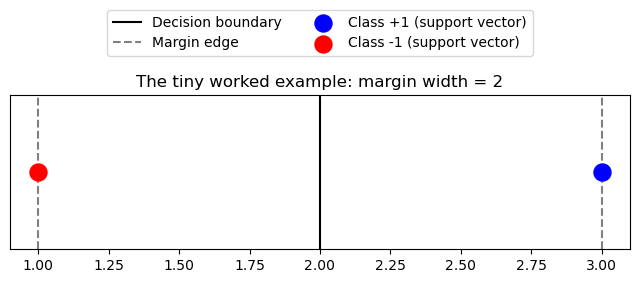

In [21]:
x_pos, x_neg = 3, 1
w, b = 1, -2
boundary = -b / w

plt.figure(figsize=(8, 2))
plt.axvline(boundary, color='black', label='Decision boundary')
plt.axvline(boundary - 1 / w, color='gray', linestyle='--', label='Margin edge')
plt.axvline(boundary + 1 / w, color='gray', linestyle='--')
plt.scatter([x_pos], [0], color='blue', s=150, label='Class +1 (support vector)', zorder=5)
plt.scatter([x_neg], [0], color='red', s=150, label='Class -1 (support vector)', zorder=5)
plt.yticks([])
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.6), ncol=2)
plt.title('The tiny worked example: margin width = 2')
plt.show()

## <font color="brown"> 5. Soft Margins: When Data Isn't Perfectly Separable

Real data is messy. Sometimes a few points will end up on the wrong side, or inside the margin, no matter where we draw the line. SVM handles this by relaxing the rule slightly: each point $i$ is allowed a small "cheat" amount $\xi_i \ge 0$ (a *slack variable*):

$$y_i (w \cdot x_i + b) \ge 1 - \xi_i$$

If $\xi_i = 0$, the point follows the original strict rule. If $\xi_i > 0$, it's allowed to sit inside the margin, or even on the wrong side, by that amount. We don't want unlimited cheating though, so we penalize it in what we're minimizing:

$$\text{minimize } \lVert w \rVert^2 + C \sum_i \xi_i$$

$C$ is a number *we* choose, and it controls the trade-off:

* **Large $C$**: cheating is expensive, so SVM tries hard to classify every point correctly, even if the margin has to get narrower. Risk: overfitting to noisy points.
* **Small $C$**: cheating is cheap, so SVM keeps a wide, stable margin even if a few points end up misclassified. Risk: underfitting.

This is the exact same idea you've already seen show up as `max_depth` in Decision Trees or `alpha` in Ridge/Lasso, a different knob, but the same underlying question: how much freedom do we give the model to chase every training point exactly?

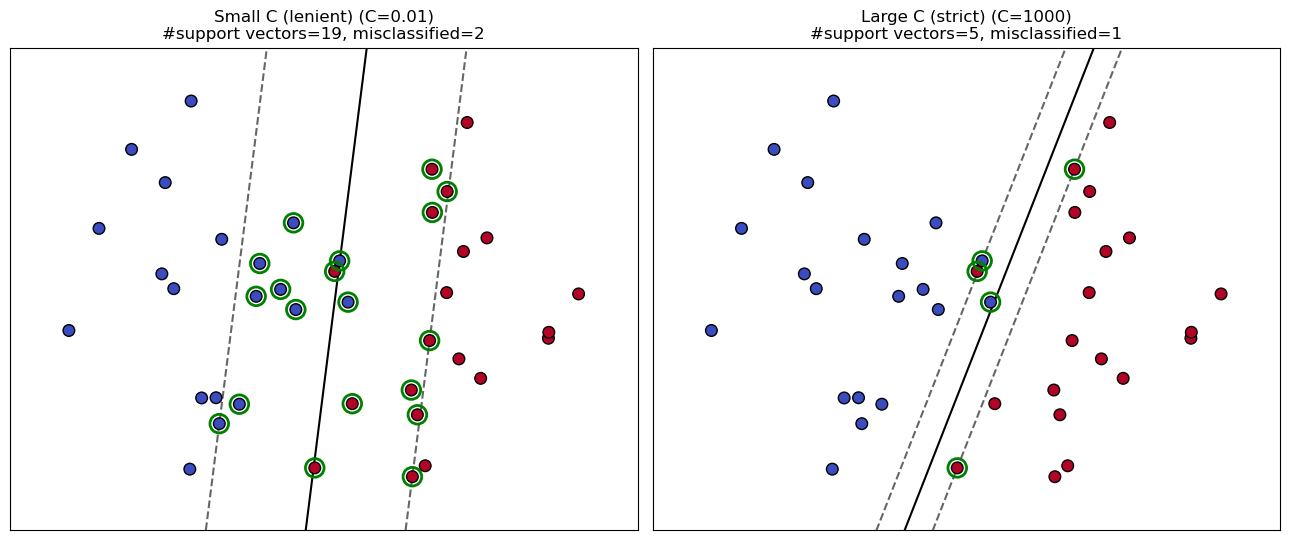

In [23]:
X_soft, y_soft = make_blobs(n_samples=40, centers=2, cluster_std=2.4, random_state=7)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, C, title in zip(axes, [0.01, 1000], ['Small C (lenient)', 'Large C (strict)']):
    m = SVC(kernel='linear', C=C).fit(X_soft, y_soft)
    ax.scatter(X_soft[:, 0], X_soft[:, 1], c=y_soft, cmap='coolwarm', edgecolors='k', s=70, zorder=3)
    w = m.coef_[0]
    b = m.intercept_[0]
    xx = np.linspace(X_soft[:, 0].min() - 1, X_soft[:, 0].max() + 1, 10)
    yy = -(w[0] * xx + b) / w[1]
    margin = 1 / np.sqrt(np.sum(w ** 2))
    factor = np.sqrt(1 + (w[0] / w[1]) ** 2)
    ax.plot(xx, yy, 'k-')
    ax.plot(xx, yy + factor * margin, 'k--', alpha=0.6)
    ax.plot(xx, yy - factor * margin, 'k--', alpha=0.6)
    ax.scatter(
        m.support_vectors_[:, 0], m.support_vectors_[:, 1],
        s=180, facecolors='none', edgecolors='green', linewidths=2, zorder=4,
    )
    n_errors = np.sum(y_soft != m.predict(X_soft))
    ax.set_title(f'{title} (C={C})\n#support vectors={len(m.support_vectors_)}, misclassified={n_errors}')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim(X_soft[:, 1].min() - 1.5, X_soft[:, 1].max() + 1.5)

plt.tight_layout()
plt.show()

Same data, same kernel, only `C` changed. With small `C`, the margin is wide and 19 points end up close enough to count as support vectors, and 2 points are misclassified in exchange for that stability. With large `C`, the margin narrows sharply, fewer support vectors, and it manages to correctly classify one more point, at the cost of a boundary that's more sensitive to exactly where these particular training points happened to fall.

## <font color="brown"> 6. Non-Linear Data: Why We Need Kernels

Everything so far assumes a *straight* boundary works. But sometimes it just doesn't, no matter how you tilt or shift a straight line, some datasets can't be separated by one. Here's the simplest possible example: points on a single number line, where the two classes are *interleaved by distance from the center*.

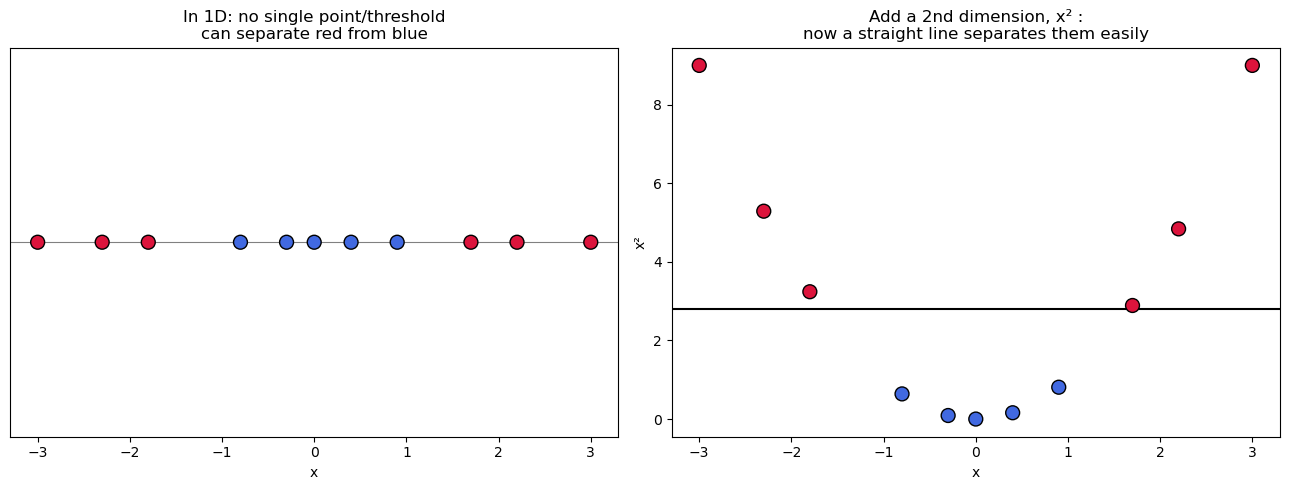

In [26]:
x = np.array([-3, -2.3, -1.8, 1.7, 2.2, 3, -0.8, -0.3, 0, 0.4, 0.9])
labels = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1])  # 0 = outer (red), 1 = inner (blue)
colors = np.where(labels == 0, 'crimson', 'royalblue')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(x, np.zeros_like(x), c=colors, s=100, edgecolors='k', zorder=3)
ax.axhline(0, color='gray', lw=0.8)
ax.set_yticks([])
ax.set_title('In 1D: no single point/threshold\ncan separate red from blue')
ax.set_xlabel('x')

ax = axes[1]
x2 = x ** 2
ax.scatter(x, x2, c=colors, s=100, edgecolors='k', zorder=3)
ax.axhline(2.8, color='black', linestyle='-')
ax.set_title('Add a 2nd dimension, x² :\nnow a straight line separates them easily')
ax.set_xlabel('x')
ax.set_ylabel('x²')

plt.tight_layout()
plt.show()

That's the entire idea behind kernels, in one picture. **If the data isn't linearly separable in its current dimension, lift it into a higher dimension where it is.** Here, simply adding $x^2$ as a second coordinate turned an impossible 1D problem into a trivial 2D one, a single straight line does the job.

The catch: figuring out the *right* transformation, and actually computing it, can be expensive or even impossible (some useful transformations lead to infinite dimensions). That's exactly the problem kernels solve, they let SVM get the *effect* of this lift without ever computing it directly (more on the mechanics in section 8).

## <font color="brown"> 7. The Common Kernels

Let's see this play out on a harder 2D example: two concentric circles, one class forms a ring around the other. No straight line can separate these, so this is a perfect test of what each kernel can actually do.

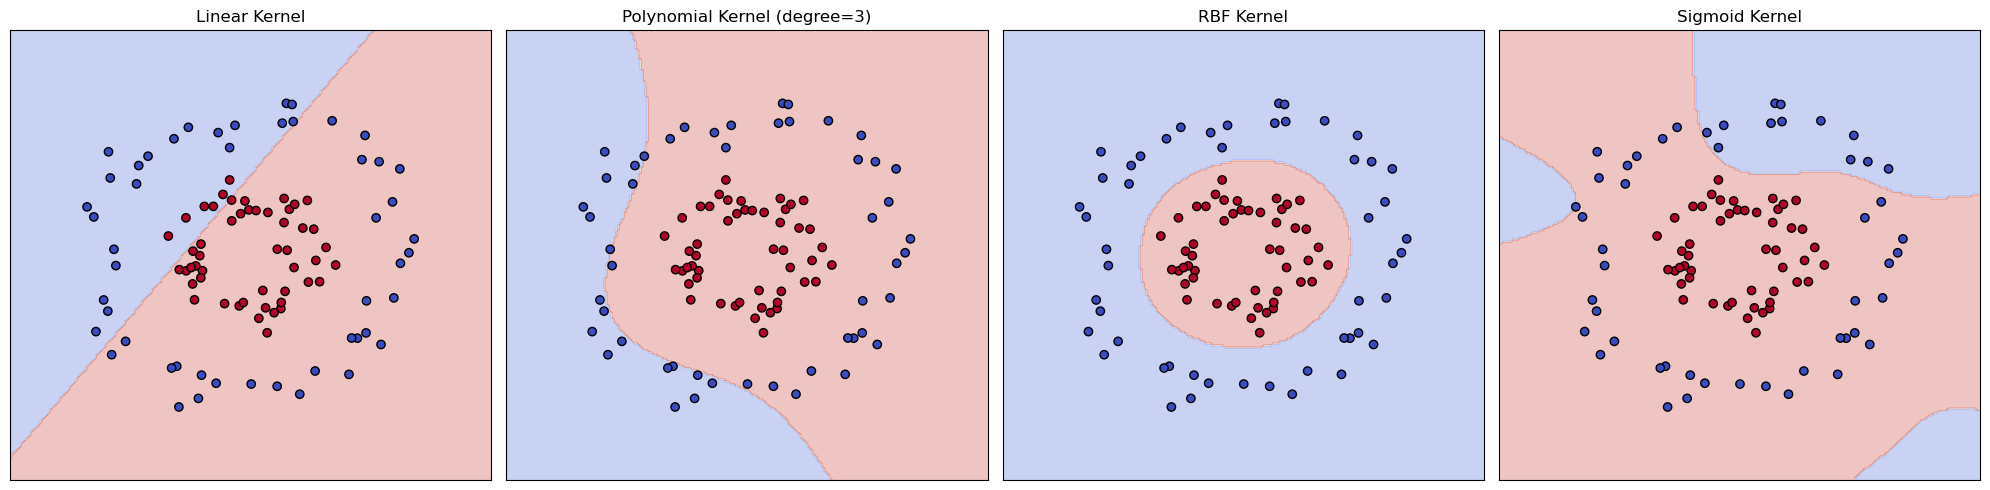

In [29]:
def plot_kernel_boundary(ax, X, y, kernel, title, **kwargs):
    m = SVC(kernel=kernel, random_state=1, **kwargs).fit(X, y)
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200),
        np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200),
    )
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


X_circle, y_circle = make_circles(n_samples=100, noise=0.1, factor=0.4, random_state=1)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
plot_kernel_boundary(axes[0], X_circle, y_circle, 'linear', 'Linear Kernel')
plot_kernel_boundary(axes[1], X_circle, y_circle, 'poly', 'Polynomial Kernel (degree=3)', degree=3)
plot_kernel_boundary(axes[2], X_circle, y_circle, 'rbf', 'RBF Kernel')
plot_kernel_boundary(axes[3], X_circle, y_circle, 'sigmoid', 'Sigmoid Kernel')
plt.tight_layout()
plt.show()

* **Linear** completely fails here, as expected, there's no straight line that separates a ring from its center.
* **Polynomial** (degree 3) manages a rough, blocky curve.
* **RBF** does this almost perfectly, a clean circular boundary tracing the inner circle. This is exactly the shape its distance-based similarity is naturally suited to, which is why it's scikit-learn's default kernel.
* **Sigmoid** produces a messy, disconnected boundary that barely captures the circular pattern at all, a good visual reminder of why it's used far less often in practice.

The formulas behind each:

| Kernel | Formula | Plain-English meaning |
| --- | --- | --- |
| Linear | $x_i \cdot x_j$ | No transformation, straight boundary |
| Polynomial | $(\gamma \, x_i \cdot x_j + r)^d$ | Adds curved, polynomial-shaped boundaries |
| RBF | $\exp(-\gamma \lVert x_i - x_j \rVert^2)$ | Similarity based on distance, smooth curved boundaries |
| Sigmoid | $\tanh(\gamma \, x_i \cdot x_j + r)$ | Neural-network-like, less predictable boundaries |

## <font color="brown"> 8. Why Kernels Work: A Peek Behind the Curtain

This is the one part of SVM that looks like magic until you see the mechanism, so let's open it up gently, without the full derivation.

### <font color="blue"> Every training point gets an importance weight, alpha

When SVM is trained, it doesn't just produce $w$ and $b$. Behind the scenes, it also assigns every single training point a number $\alpha_i \ge 0$ (this comes from a technique called *Lagrange multipliers*, we won't derive it, just use the result). This number says how much "influence" that point has on the final boundary.

**The key fact**: for every point that is *not* a support vector, $\alpha_i$ works out to be exactly zero. Only the support vectors get $\alpha_i > 0$. That's the precise mathematical reason only support vectors matter, every other point's weight in the final formula is multiplied by zero.

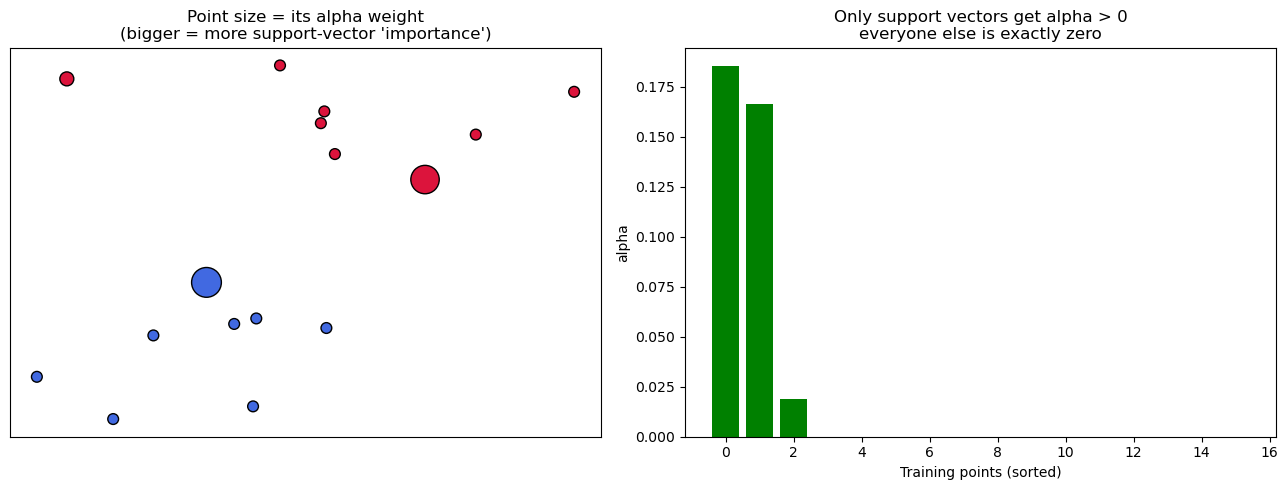

In [32]:
X_alpha, y_alpha = make_blobs(n_samples=16, centers=2, cluster_std=1.0, random_state=6)
m = SVC(kernel='linear', C=10).fit(X_alpha, y_alpha)

alphas = np.zeros(len(X_alpha))
alphas[m.support_] = np.abs(m.dual_coef_[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sizes = 60 + 400 * alphas / alphas.max()
colors = np.where(y_alpha == 0, 'crimson', 'royalblue')
ax.scatter(X_alpha[:, 0], X_alpha[:, 1], c=colors, s=sizes, edgecolors='k', zorder=3)
ax.set_title("Point size = its alpha weight\n(bigger = more support-vector 'importance')")
ax.set_xticks([])
ax.set_yticks([])

ax = axes[1]
order = np.argsort(-alphas)
ax.bar(range(len(X_alpha)), alphas[order], color=['green' if a > 1e-6 else 'lightgray' for a in alphas[order]])
ax.set_xlabel('Training points (sorted)')
ax.set_ylabel('alpha')
ax.set_title('Only support vectors get alpha > 0\neveryone else is exactly zero')

plt.tight_layout()
plt.show()

### <font color="blue"> Why this makes the kernel trick possible

With these $\alpha_i$ weights, it turns out the entire trained model, both fitting it and using it to predict, can be rewritten so that **the data points only ever appear in pairs, multiplied together** (as a dot product $x_i \cdot x_j$), never on their own. Roughly:

$$\text{prediction for a new point } x = \text{sign}\left(\sum_i \alpha_i y_i (x_i \cdot x) + b\right)$$

Look closely: $x_i \cdot x$ is just a dot product between a training point and the new point. Since $\alpha_i = 0$ for every non-support-vector, this sum only really involves the support vectors.

Now recall from Section 6 that solving a non-linear problem means lifting every point into a higher-dimensional space with some transformation $\phi$, i.e. replacing $x$ with $\phi(x)$ everywhere. If we did that literally, the formula above would need $\phi(x_i) \cdot \phi(x)$ instead of $x_i \cdot x$, computing $\phi$ for every point.

**The kernel trick**: a kernel function $K(x_i, x_j)$ computes $\phi(x_i) \cdot \phi(x_j)$ *directly*, without ever computing $\phi$ itself:

$$K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)$$

So all we do is swap $x_i \cdot x$ for $K(x_i, x)$ in the prediction formula above, and we get all the benefit of the higher-dimensional space (even an infinite-dimensional one, in RBF's case) at the computational cost of working in the original space. That swap is the entire "trick".

## <font color="brown"> 9. Multi-Class SVM, Briefly

Everything above assumes two classes ($+1$ and $-1$). Most real problems (like our loan purpose column with 10 categories) have more. scikit-learn handles this automatically using one of two strategies:

* **One-vs-Rest (OvR)**: train one binary SVM per class ("is it class A or not?", "is it class B or not?", ...), and predict whichever classifier is most confident.
* **One-vs-One (OvO)**: train one binary SVM for every *pair* of classes, and let them vote. This is what scikit-learn's `SVC` uses internally by default.

You don't need to configure this yourself, just be aware it's happening under the hood whenever your target has more than two classes.

## <font color="brown"> 10. Strengths, Weaknesses, and When to Reach for SVM

**Strengths**
* Works well even with a high number of features relative to the number of rows.
* The kernel trick makes it genuinely good at non-linear boundaries, when the right kernel is used.
* The margin-maximizing objective tends to generalise well, especially with a well-tuned `C`.

**Weaknesses**
* Training time scales poorly with the number of rows (we saw this directly in `SVM.ipynb`, a single kernel took over a minute on ~24,000 rows), which is why we trained on a sample there.
* No natural probability output, `predict_proba` exists but is an extra, somewhat expensive calibration step layered on top, not something SVM produces directly.
* Choosing the right kernel and tuning `C`/`gamma` well requires experimentation, there's no single default that works everywhere.
* Like most models here, it's sensitive to feature scaling, always scale your features first.

**Rule of thumb**: start with a linear kernel as a fast, interpretable baseline. Only move to RBF or polynomial if you have concrete evidence (like a 2D plot, or a linear model clearly underperforming) that the true boundary is genuinely non-linear.

## <font color="brown"> 11. Summary Cheat Sheet

* SVM finds the boundary with the **widest margin** between classes.
* Only the closest points, the **support vectors**, define that boundary, everything else could vanish without changing it.
* Maximizing the margin is mathematically the same as **minimizing $\lVert w \rVert$**.
* **$C$** trades off margin width against training mistakes: big $C$ = stricter (risk of overfitting), small $C$ = more lenient (risk of underfitting).
* **Kernels** let SVM draw curved boundaries by implicitly working in a higher-dimensional space, without ever computing that space directly.
* This works because training assigns every point an **alpha weight**, which is exactly zero for everything except the support vectors, so the model only ever needs dot products between pairs of points, which is exactly what a kernel computes.
* **Start with linear.** Only reach for RBF/polynomial when there's real, visible non-linear structure in the data.